In [1]:
!pip install roboflow torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [2]:
import os
import torch
import torchvision
import numpy as np
from PIL import Image

from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
import torchvision.transforms as T

In [3]:
from roboflow import Roboflow


rf = Roboflow(api_key="FubcSJVDHEnV0FhKPMWy")
project = rf.workspace("nguyns-workspace-th4ak").project("dengue-fever-detection")
version = project.version(1)

dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dengue-fever-detection-1 in coco:: 100%|██████████| 3193/3193 [00:01<00:00, 2526.54it/s]


In [4]:
from torchvision.datasets import CocoDetection
import torch
import os
from PIL import Image

class RoboflowDetection(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):

        super().__init__(img_folder, ann_file, transforms=None)
        self.custom_transforms = transforms


        original_ids = list(self.ids)
        self.ids = []



        for img_id in original_ids:

            ann_ids = self.coco.getAnnIds(imgIds=img_id, iscrowd=None)
            if ann_ids:
                self.ids.append(img_id)

    def __getitem__(self, idx):

        img, target_coco = super().__getitem__(idx)

        boxes = []
        labels = []

        for obj in target_coco:
            x, y, w, h = obj['bbox']

            boxes.append([x, y, x+w, y+h])
            labels.append(1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)


        coco_img_id = self.ids[idx]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([coco_img_id])         }


        if self.custom_transforms:
            img = self.custom_transforms(img)

        return img, target

In [5]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [6]:
import torchvision.transforms as T

transforms = T.Compose([
    T.ToTensor()
])

In [7]:
import os
from torch.utils.data import DataLoader

train_dataset = RoboflowDetection(
    img_folder=os.path.join(dataset.location, "train"),
    ann_file=os.path.join(dataset.location, "train/_annotations.coco.json"),
    transforms=transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers = 2,
    collate_fn=collate_fn
)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [8]:
images, targets = next(iter(train_loader))

print(images[0].shape)
print(targets[0])

torch.Size([3, 512, 512])
{'boxes': tensor([[300.,  23., 512., 204.]]), 'labels': tensor([1]), 'image_id': tensor([2137])}


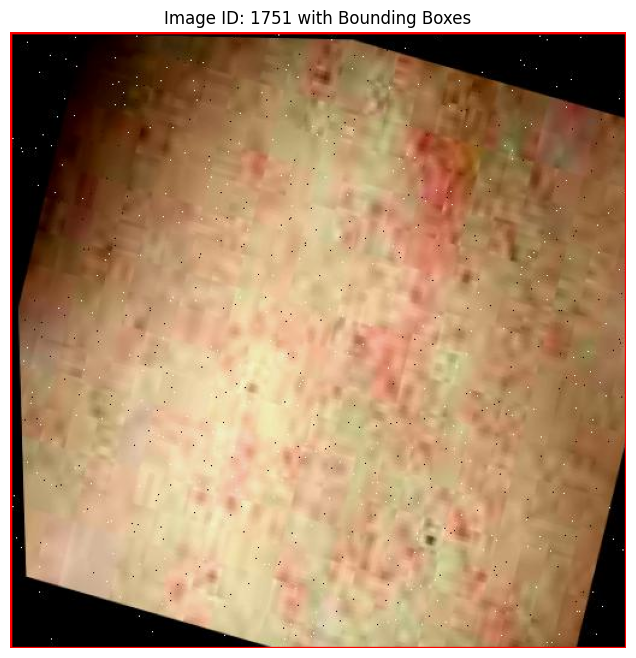

In [9]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Get one batch from the train_loader
# Assuming train_loader is already defined and provides images and targets
images, targets = next(iter(train_loader))

# Take the first image and its corresponding target for visualization
image_tensor = images[2]
target_data = targets[2]

# Convert the image tensor (C, H, W) to a NumPy array (H, W, C) for visualization
# The image tensor values are typically floats between 0 and 1
img_np = image_tensor.permute(1, 2, 0).cpu().numpy()

# Scale to 0-255 and convert to uint8 for OpenCV, as it generally expects byte images.
# Matplotlib can handle float images directly if they are in [0, 1] range.
img_to_draw = (img_np * 255).astype(np.uint8)

# Extract bounding boxes from the target data
# boxes are already in [x1, y1, x2, y2] pixel format
boxes = target_data['boxes'].cpu().numpy()

# Make a copy of the image to draw on
img_with_bbox = img_to_draw.copy()

# Draw bounding boxes on the image
if len(boxes) > 0:
    for bbox in boxes:
        x1, y1, x2, y2 = bbox.astype(int)
        # Draw a red rectangle (255, 0, 0)
        img_with_bbox = cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(8, 8)) # Optional: set figure size
plt.imshow(img_with_bbox)
plt.title(f"Image ID: {target_data['image_id'].item()} with Bounding Boxes")
plt.axis('off') # Optional: turn off axis labels
plt.show()

In [10]:
print(train_dataset.coco.dataset['categories'])

[{'id': 0, 'name': 'objects', 'supercategory': 'none'}, {'id': 1, 'name': 'dengue-rash', 'supercategory': 'objects'}]


In [11]:
import torchvision

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 150MB/s]


In [12]:
num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [14]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    # total_loss = 0 # No longer needed

    for images, targets in loader:


        images = [img for img, t in zip(images, targets) if len(t["boxes"]) > 0]
        targets = [t for t in targets if len(t["boxes"]) > 0]

        if len(images) == 0:
            continue

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # total_loss += losses.item() # No longer needed
    return loss_dict

In [ ]:
for epoch in range(10):
    loss_dict = train_one_epoch(model, train_loader, optimizer)
    print(loss_dict)

{'loss_classifier': tensor(0.0981, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1239, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0378, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0120, device='cuda:0', grad_fn=<DivBackward0>)}
{'loss_classifier': tensor(0.1061, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1385, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0324, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0099, device='cuda:0', grad_fn=<DivBackward0>)}
{'loss_classifier': tensor(0.1032, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1339, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0199, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0069, device='cuda:0', grad_fn=

In [ ]:
model.eval()

images, _ = next(iter(train_loader))
images = [img.to(device) for img in images]

outputs = model(images)

print(outputs[0])

In [ ]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.ops as ops # Import for NMS

# Get one batch from the train_loader
images, targets = next(iter(train_loader))

# Take the third image and its corresponding target for visualization
image_tensor = images[2]
original_target_data = targets[2]

# Ensure model is in eval mode and get one batch of predictions
model.eval()
image_tensor_to_model = image_tensor.to(device)
with torch.no_grad():
    outputs_from_model = model([image_tensor_to_model])
predicted_data = outputs_from_model[0]

# Convert the image tensor (C, H, W) to a NumPy array (H, W, C) for visualization
img_np = image_tensor.permute(1, 2, 0).cpu().numpy()
img_to_draw = (img_np * 255).astype(np.uint8)

# --- Process Predicted Bounding Boxes ---
predicted_boxes = predicted_data['boxes'].cpu().detach()
predicted_scores = predicted_data['scores'].cpu().detach()

# Apply Non-Maximum Suppression (NMS)
iou_threshold = 0.02 # You can adjust this as needed
nms_indices = ops.nms(predicted_boxes, predicted_scores, iou_threshold)

# Filter boxes and scores based on NMS indices
filtered_predicted_boxes = predicted_boxes[nms_indices].numpy()
filtered_predicted_scores = predicted_scores[nms_indices].numpy()

# Add a confidence threshold for predictions
confidence_threshold = 0.5
confident_indices = filtered_predicted_scores > confidence_threshold
final_predicted_boxes = filtered_predicted_boxes[confident_indices]
final_predicted_scores = filtered_predicted_scores[confident_indices]

# --- Draw both Ground Truth and Predicted Bounding Boxes on a single image ---
img_combined = img_to_draw.copy()

# Draw Ground Truth Bounding Boxes (Green color)
original_boxes = original_target_data['boxes'].cpu().numpy()
if len(original_boxes) > 0:
    for bbox in original_boxes:
        x1, y1, x2, y2 = bbox.astype(int)
        cv2.rectangle(img_combined, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green for ground truth (BGR format)

# Draw Predicted Bounding Boxes (Red color)
if len(final_predicted_boxes) > 0:
    for bbox, score in zip(final_predicted_boxes, final_predicted_scores):
        x1, y1, x2, y2 = bbox.astype(int)
        cv2.rectangle(img_combined, (x1, y1), (x2, y2), (255, 0, 0), 2) # Red for predictions (BGR format)

        text = f"{score:.2f}"
        text_x = x1
        text_y = y1 - 10 if y1 - 10 > 10 else y1 + 10
        cv2.putText(img_combined, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)

plt.figure(figsize=(10, 10)) # Adjust figure size as needed
plt.imshow(img_combined)
plt.title(f"Image ID: {original_target_data['image_id'].item()} (GT Green, Pred Red, confidence > {confidence_threshold})")
plt.axis('off')
plt.show()

In [ ]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
model.eval()

total_boxes = 0

for images, targets in train_loader:
    images = [img.to(device) for img in images]
    outputs = model(images)

    total_boxes += len(outputs[0]["boxes"])
    break

print("Predicted boxes:", total_boxes)